### import packages

In [2]:
import scanpy as sc
import pandas as pd
import numpy as np
import torch
import dgl
import random
from scipy.sparse import csr_matrix
from sklearn.metrics import adjusted_rand_score as ari_score
from sklearn.metrics.cluster import normalized_mutual_info_score

C:\Users\10360\anaconda3\envs\CAMEX_t\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
from stAggregator import stAggregator
from stAggregator import metrics
from stAggregator.data import process_adata, process_graph
from stAggregator.data import process_graph

In [4]:
from sklearn.metrics import adjusted_rand_score as ari_score
from sklearn.metrics.cluster import normalized_mutual_info_score

In [5]:
seed = 42
random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
np.random.seed(seed)
dgl.random.seed(seed)

In [6]:
def refine_label(adata, radius=50, key='label'):
    import ot
    n_neigh = radius
    new_type = []
    old_type = adata.obs[key].values
    
    #calculate distance
    position = adata.obsm['spatial']
    distance = ot.dist(position, position, metric='euclidean')
           
    n_cell = distance.shape[0]
    
    for i in range(n_cell):
        vec  = distance[i, :]
        index = vec.argsort()
        neigh_type = []
        for j in range(1, n_neigh+1):
            neigh_type.append(old_type[index[j]])
        max_type = max(neigh_type, key=neigh_type.count)
        new_type.append(max_type)
        
    new_type = [str(i) for i in list(new_type)]    
    #adata.obs['label_refined'] = np.array(new_type)
    
    return new_type

In [7]:
def mclust_R(adata, num_cluster, modelNames='EEE', used_obsm='emb_pca', random_seed=42):
    """\
    Clustering using the mclust algorithm.
    The parameters are the same as those in the R package mclust.
    """

    np.random.seed(random_seed)
    import rpy2.robjects as robjects
    robjects.r.library("mclust")

    import rpy2.robjects.numpy2ri
    rpy2.robjects.numpy2ri.activate()
    r_random_seed = robjects.r['set.seed']
    r_random_seed(random_seed)
    rmclust = robjects.r['Mclust']

    res = rmclust(rpy2.robjects.numpy2ri.numpy2rpy(adata.obsm[used_obsm]), num_cluster, modelNames)
    mclust_res = np.array(res[-2])

    adata.obs['mclust'] = mclust_res
    adata.obs['mclust'] = adata.obs['mclust'].astype('int')
    adata.obs['mclust'] = adata.obs['mclust'].astype('category')
    adata.obsm['mclust_prob'] = np.array(res[-3])
    return adata

In [8]:
def mclust_R_smooth(adata, num_cluster, modelNames='EEE', used_obsm='emb_pca', random_seed=42):
    """\
    Clustering using the mclust algorithm.
    The parameters are the same as those in the R package mclust.
    """

    np.random.seed(random_seed)
    import rpy2.robjects as robjects
    robjects.r.library("mclust")

    import rpy2.robjects.numpy2ri
    rpy2.robjects.numpy2ri.activate()
    r_random_seed = robjects.r['set.seed']
    r_random_seed(random_seed)
    rmclust = robjects.r['Mclust']

    res = rmclust(rpy2.robjects.numpy2ri.numpy2rpy(adata.obsm[used_obsm]), num_cluster, modelNames)
    mclust_res = np.array(res[-2])

    adata.obs['mclust'] = mclust_res
    adata.obs['mclust'] = adata.obs['mclust'].astype('int')
    adata.obs['mclust'] = adata.obs['mclust'].astype('category')
    adata.obsm['mclust_prob'] = np.array(res[-3])

    adata.obs['mclust'] = refine_label(adata, 50, key='mclust')
    
    return adata

In [9]:
def clear_fig(fig):
    if fig:
        fig.axes[0].set_xlabel(None)
        fig.axes[0].set_ylabel(None)
        fig.tight_layout()
        fig.gca().invert_yaxis()
        # fig.gca().invert_xaxis()
    else:
        pass
    return fig

In [11]:
sc.set_figure_params(dpi=150, figsize=(2, 2), frameon=False)    # 

### load data and train

In [20]:
adata = sc.read_h5ad(f'./Mouse_brain.h5ad')
adata.obs_names_make_unique()
adata.var_names_make_unique()
data_list = [adata]
batch_key = 'batch'
batch_names = ['adata']

adata = process_adata(data_list, batch_key=batch_key, batch_categories=batch_names, n_top_features=5000)
rad_cutoff_list = [2]
adata = process_graph(adata, data_list, rad_cutoff_list=rad_cutoff_list)
path_results = f'./log/integration/'
adata_stAggregator = stAggregator(adata=adata, max_iteration=800, outdir=path_results, h_dim=16,
                       batch_size=1024, impute=False, early_stop=False, random_seed=42)


------Calculating spatial graph...
The graph contains 363082 edges, 38746 cells.
9.3708 neighbors per cell on average.


Epochs: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 21/21 [02:15<00:00,  6.43s/it, recon_loss_mse=17216.967, sl1_loss=52.370, sl2_loss=51.846, lr: 0.001]
2024-06-25 19:04:39,467 - root - INFO - Output dir: ./log/integration/
2024-06-25 19:04:39,467 - root - INFO - Output dir: ./log/integration/


In [11]:
path_results = f'./log/integration/'
adata_stAggregator = sc.read_h5ad('./log/integration/adata_stAggregator.h5ad')

In [12]:
adata_stAggregator

AnnData object with n_obs × n_vars = 38746 × 5000
    obs: 'annotation', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'batch'
    var: 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'highly_variable_nbatches'
    uns: 'hvg', 'log1p'
    obsm: 'X_emb', 'X_stAggregator', 'feature_scale', 'spatial'
    layers: 'count', 'counts'

In [13]:
sc.pp.neighbors(adata_stAggregator, use_rep='X_stAggregator')

In [14]:
sc.tl.umap(adata_stAggregator)

In [15]:
sc.tl.louvain(adata_stAggregator, resolution=0.7)

In [16]:
sc.tl.leiden(adata_stAggregator, resolution=0.5)

In [17]:
adata_stAggregator = mclust_R(adata_stAggregator, used_obsm='X_stAggregator', num_cluster=20)

R[write to console]:                    __           __ 
   ____ ___  _____/ /_  _______/ /_
  / __ `__ \/ ___/ / / / / ___/ __/
 / / / / / / /__/ / /_/ (__  ) /_  
/_/ /_/ /_/\___/_/\__,_/____/\__/   version 6.0.0
Type 'citation("mclust")' for citing this R package in publications.



fitting ...
  |======================================================================| 100%


In [18]:
adata_stAggregator.obs['mclust'] = adata_stAggregator.obs['mclust']

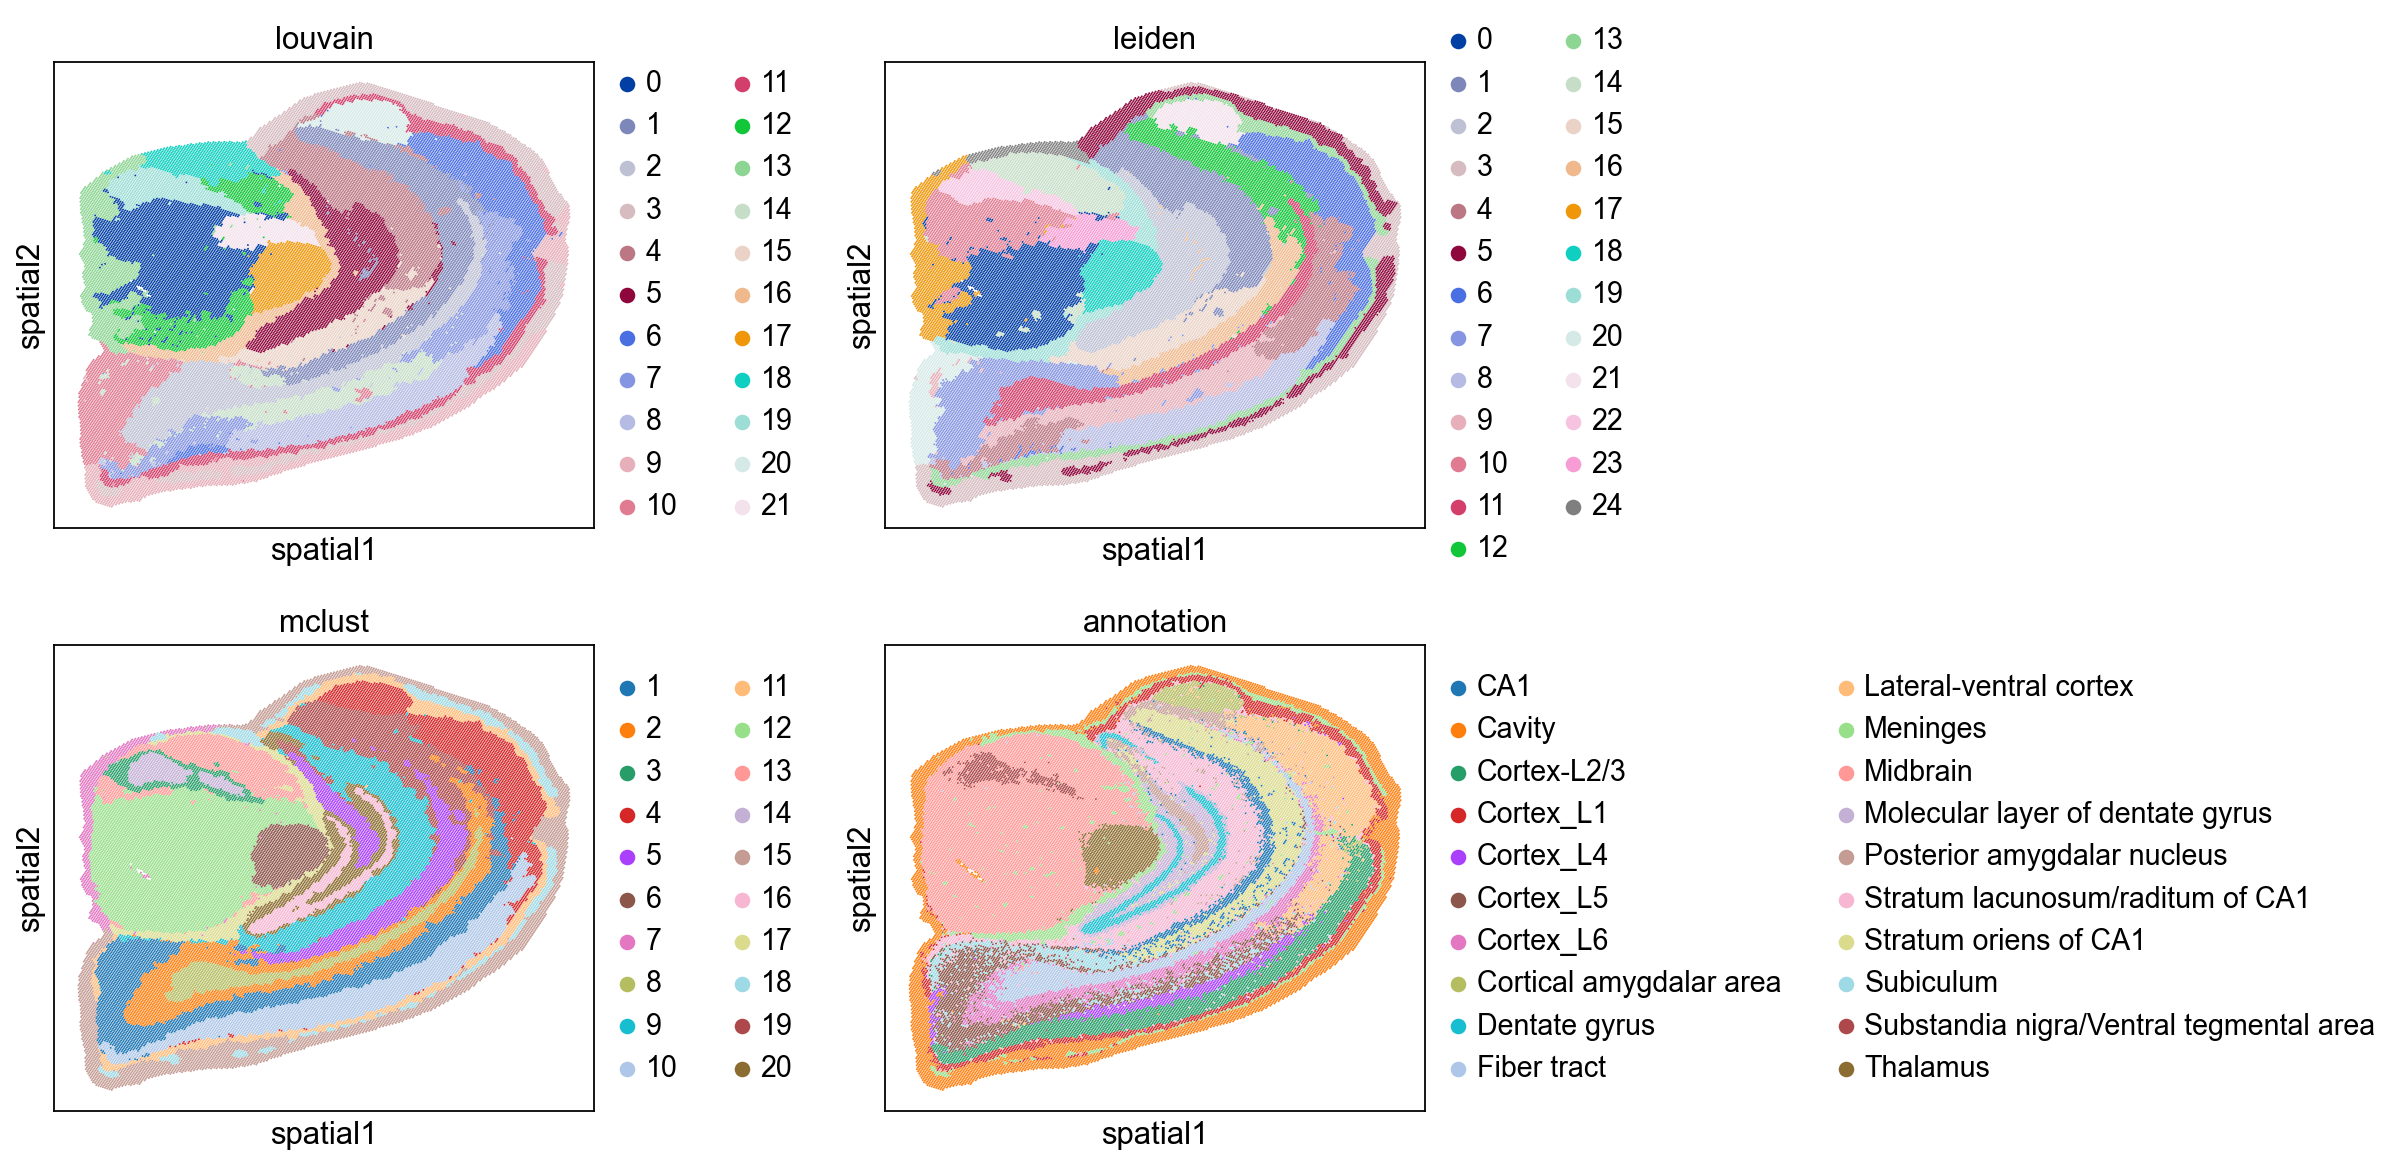

In [29]:
sc.pl.embedding(adata_stAggregator, basis='spatial', color=['louvain', 'leiden', 'mclust', 'annotation'], wspace=0.4, ncols=2)